# Credit Scoring PD(probability of default) Model

# Pre-Processing

In [1]:
# Kitabxanalari oxumaq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
pd.set_option('display.max_columns', None)

In [2]:
# datani oxumaq
path=r'‪C:\Users\User\Downloads\credit_score.csv'
data=pd.read_csv(path[1:])
data

,ID,CustomerID,Month,Name,Age,SSN,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,TypeofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore
0,0x1602,CUS0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,11.27,4.0,809.98,26.822620,No,49.574949,80.415295,HighspentSmallvaluepayments,312.494089,Good
1,0x1603,CUS0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,809.98,31.944960,No,49.574949,118.280222,LowspentLargevaluepayments,284.629163,Good
2,0x1604,CUS0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,NaN,4.0,809.98,28.609352,No,49.574949,81.699521,LowspentMediumvaluepayments,331.209863,Good
3,0x1605,CUS0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4.0,6.27,4.0,809.98,31.377862,No,49.574949,199.458074,LowspentSmallvaluepayments,223.451310,Good
4,0x1606,CUS0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,809.98,24.797347,No,49.574949,41.420153,HighspentMediumvaluepayments,341.489231,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87490,0x25fe8,CUS0x942c,March,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,6.0,9.50,3.0,502.38,39.323569,No,35.104023,140.581403,HighspentMediumvaluepayments,410.256158,Poor
87491,0x25fe9,CUS0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7.0,11.50,3.0,502.38,34.663572,No,35.104023,60.971333,HighspentLargevaluepayments,479.866228,Poor
87492,0x25fea,CUS0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7.0,11.50,3.0,502.38,40.565631,No,35.104023,54.185950,HighspentMediumvaluepayments,496.651610,Poor
87493,0x25feb,CUS0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6.0,11.50,3.0,502.38,41.255522,No,35.104023,24.028477,HighspentLargevaluepayments,516.809083,Poor


In [3]:
# descriptive statistika
data.describe(include='all')

,ID,CustomerID,Month,Name,Age,SSN,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,TypeofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore
count,87495,87495,87495,78779,87495.000000,87495,81317,8.749500e+04,74319.000000,87495.000000,87495.000000,87495.000000,87495.000000,77583,87495.000000,81400.000000,85654.000000,85789.000000,87495.000000,87495.000000,87495,87495.000000,79786.000000,87495,86437.000000,87495
unique,87495,12500,8,10139,NaN,12501,15,NaN,NaN,NaN,NaN,NaN,NaN,6260,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,7,NaN,3
top,0x1602,CUS0xd40,January,Langep,NaN,#F%$D@*&8,Lawyer,NaN,NaN,NaN,NaN,NaN,NaN,Not Specified,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,LowspentSmallvaluepayments,NaN,Standard
freq,1,8,10970,41,NaN,4857,5762,NaN,NaN,NaN,NaN,NaN,NaN,1208,NaN,NaN,NaN,NaN,NaN,NaN,45810,NaN,NaN,22237,NaN,46651
mean,NaN,NaN,NaN,NaN,110.467364,NaN,NaN,1.802404e+05,4193.181285,17.112646,22.664792,73.050871,7.019841,NaN,21.060403,30.904324,10.385851,27.734302,1426.716635,32.290526,NaN,1388.517947,195.482486,NaN,402.281023,NaN
std,NaN,NaN,NaN,NaN,686.549658,NaN,NaN,1.455212e+06,3179.195651,117.428586,129.806747,467.727237,60.352339,NaN,14.864558,225.495250,6.776714,193.011903,1155.824064,5.112418,NaN,8248.832131,199.357752,NaN,213.309331,NaN
min,NaN,NaN,NaN,NaN,-500.000000,NaN,NaN,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,NaN,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,NaN,0.000000,0.000000,NaN,0.007760,NaN
25%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,1.943348e+04,1626.677917,3.000000,4.000000,8.000000,1.000000,NaN,10.000000,9.000000,5.340000,3.000000,566.400000,28.059063,NaN,30.453014,72.220853,NaN,270.107156,NaN
50%,NaN,NaN,NaN,NaN,33.000000,NaN,NaN,3.757975e+04,3095.905000,6.000000,5.000000,13.000000,3.000000,NaN,18.000000,14.000000,9.410000,6.000000,1166.230000,32.322206,NaN,69.285581,128.921405,NaN,336.698600,NaN
75%,NaN,NaN,NaN,NaN,42.000000,NaN,NaN,7.288608e+04,5967.930000,7.000000,7.000000,20.000000,5.000000,NaN,28.000000,18.000000,14.840000,9.000000,1948.980000,36.495606,NaN,161.405543,236.802042,NaN,470.180816,NaN


In [4]:
# lazimsiz sutunlar drop olunur
data.drop(data[['ID']],axis=1,inplace=True)

In [5]:
data.drop(data[['CustomerID','SSN','Name','TypeofLoan']],axis=1,inplace=True)

In [6]:
data

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,4.0,809.98,26.822620,No,49.574949,80.415295,HighspentSmallvaluepayments,312.494089,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,-1,NaN,11.27,4.0,809.98,31.944960,No,49.574949,118.280222,LowspentLargevaluepayments,284.629163,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,3,7.0,NaN,4.0,809.98,28.609352,No,49.574949,81.699521,LowspentMediumvaluepayments,331.209863,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,5,4.0,6.27,4.0,809.98,31.377862,No,49.574949,199.458074,LowspentSmallvaluepayments,223.451310,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,6,NaN,11.27,4.0,809.98,24.797347,No,49.574949,41.420153,HighspentMediumvaluepayments,341.489231,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87490,March,25,Mechanic,39628.99,3359.415833,4,6,7,2,20,6.0,9.50,3.0,502.38,39.323569,No,35.104023,140.581403,HighspentMediumvaluepayments,410.256158,Poor
87491,April,25,Mechanic,39628.99,3359.415833,4,6,7,2,23,7.0,11.50,3.0,502.38,34.663572,No,35.104023,60.971333,HighspentLargevaluepayments,479.866228,Poor
87492,May,25,Mechanic,39628.99,3359.415833,4,6,7,2,18,7.0,11.50,3.0,502.38,40.565631,No,35.104023,54.185950,HighspentMediumvaluepayments,496.651610,Poor
87493,June,25,Mechanic,39628.99,3359.415833,4,6,5729,2,27,6.0,11.50,3.0,502.38,41.255522,No,35.104023,24.028477,HighspentLargevaluepayments,516.809083,Poor


In [7]:
# asili deyishenin yaradilmasi

# credit score sutununda 3 deyer var : good , poor ve standart.
# score adli sutun yaradilir, hardaki credit_score sutunun deyerleri poor deyilse 0 yazilir , poor olanlar 1 yazilir
# yeni yaradilan score sutunu olur asili deyishen ve 2 deyeri olur 0 ve 1

data['score'] = np.where(data['CreditScore']=='Poor',1,0)

In [8]:
data.drop('CreditScore',axis=1,inplace=True)

In [9]:
# score sutunun deyerleri sayi value_counts() ile yoxlayiriq
data.score.value_counts()

score
0    62145
1    25350
Name: count, dtype: int64

In [10]:
# data-da missing deyeleri yoxlayiriq, varsa evez edirik ( mean , min, max, mode and etc. )

# P.s for loop ile yazilmasi ustunlukdur
data.isnull().sum()

Month                         0
Age                           0
Occupation                 6178
AnnualIncome                  0
MonthlyInhandSalary       13176
NumBankAccounts               0
NumCreditCard                 0
InterestRate                  0
NumofLoan                     0
Delayfromduedate              0
NumofDelayedPayment        6095
ChangedCreditLimit         1841
NumCreditInquiries         1706
OutstandingDebt               0
CreditUtilizationRatio        0
PaymentofMinAmount            0
TotalEMIpermonth              0
Amountinvestedmonthly      7709
PaymentBehaviour              0
MonthlyBalance             1058
score                         0
dtype: int64

In [11]:
for column in data.columns:
    if data[column].dtypes==object:
        data[column]=data[column].fillna(data[column].mode()[0])
    else:
        data[column]=data[column].fillna(data[column].mean())
        
data.isnull().sum()    

Month                     0
Age                       0
Occupation                0
AnnualIncome              0
MonthlyInhandSalary       0
NumBankAccounts           0
NumCreditCard             0
InterestRate              0
NumofLoan                 0
Delayfromduedate          0
NumofDelayedPayment       0
ChangedCreditLimit        0
NumCreditInquiries        0
OutstandingDebt           0
CreditUtilizationRatio    0
PaymentofMinAmount        0
TotalEMIpermonth          0
Amountinvestedmonthly     0
PaymentBehaviour          0
MonthlyBalance            0
score                     0
dtype: int64

In [12]:
data.describe(include='all')

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,score
count,87495,87495.000000,87495,8.749500e+04,87495.000000,87495.000000,87495.000000,87495.000000,87495.000000,87495.000000,87495.000000,87495.000000,87495.000000,87495.000000,87495.000000,87495,87495.000000,87495.000000,87495,87495.000000,87495.000000
unique,8,NaN,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,7,NaN,NaN
top,January,NaN,Lawyer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,NaN,LowspentSmallvaluepayments,NaN,NaN
freq,10970,NaN,11940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45810,NaN,NaN,22237,NaN,NaN
mean,NaN,110.467364,NaN,1.802404e+05,4193.181285,17.112646,22.664792,73.050871,7.019841,21.060403,30.904324,10.385851,27.734302,1426.716635,32.290526,NaN,1388.517947,195.482486,NaN,402.281023,0.289731
std,NaN,686.549658,NaN,1.455212e+06,2930.050642,117.428586,129.806747,467.727237,60.352339,14.864558,217.499267,6.705039,191.120920,1155.824064,5.112418,NaN,8248.832131,190.372677,NaN,212.015713,0.453640
min,NaN,-500.000000,NaN,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,NaN,0.000000,0.000000,NaN,0.007760,0.000000
25%,NaN,24.000000,NaN,1.943348e+04,1792.520417,3.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.425000,3.000000,566.400000,28.059063,NaN,30.453014,76.962414,NaN,270.918218,0.000000
50%,NaN,33.000000,NaN,3.757975e+04,3860.632500,6.000000,5.000000,13.000000,3.000000,18.000000,15.000000,9.560000,6.000000,1166.230000,32.322206,NaN,69.285581,143.312984,NaN,338.590600,0.000000
75%,NaN,42.000000,NaN,7.288608e+04,5376.236667,7.000000,7.000000,20.000000,5.000000,28.000000,19.000000,14.640000,9.000000,1948.980000,36.495606,NaN,161.405543,219.931271,NaN,467.662120,1.000000


In [13]:
for var in data.columns:
    if var == 'score':
        continue  

    if data[var].dtypes != object:
        
        q1 = data[var].quantile(0.25)
        q2 = data[var].quantile(0.5)
        q3 = data[var].quantile(0.75)

        ranges = [-np.inf, q1, q2, q3, np.inf]
        data['category_' + var] = pd.cut(data[var], bins=ranges, duplicates='drop')

        grouped = data.groupby(['category_' + var, 'score'])['score'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data = data.merge(grouped[['category_' + var, var + '_woe']], how='left', on='category_' + var)

    elif data[var].dtypes == object:

        grouped = data.groupby([var, 'score'])['score'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data = data.merge(grouped[[var, var + '_woe']], how='left', on=var)

C:\Users\User\AppData\Local\Temp\ipykernel_13520\1268744386.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(['category_' + var, 'score'])['score'].count().unstack().reset_index()
C:\Users\User\AppData\Local\Temp\ipykernel_13520\1268744386.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(['category_' + var, 'score'])['score'].count().unstack().reset_index()
C:\Users\User\AppData\Local\Temp\ipykernel_13520\1268744386.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fal

In [14]:
data.isnull().sum()

Month                              0
Age                                0
Occupation                         0
AnnualIncome                       0
MonthlyInhandSalary                0
NumBankAccounts                    0
NumCreditCard                      0
InterestRate                       0
NumofLoan                          0
Delayfromduedate                   0
NumofDelayedPayment                0
ChangedCreditLimit                 0
NumCreditInquiries                 0
OutstandingDebt                    0
CreditUtilizationRatio             0
PaymentofMinAmount                 0
TotalEMIpermonth                   0
Amountinvestedmonthly              0
PaymentBehaviour                   0
MonthlyBalance                     0
score                              0
Month_woe                          0
category_Age                       0
Age_woe                            0
Occupation_woe                     0
category_AnnualIncome              0
AnnualIncome_woe                   0
c

In [15]:
# datada sutunlar uzre paylanma (normal or not normal distribution) yoxlanilir.
from scipy import stats

for i in data.columns:
    if data[i].dtype in ['int64','float64']:
        kstest_statistic,kstest_p_value=stats.kstest(data[i],'norm')

        print(f"Column: {i}")
        print(f"Test statistic : {kstest_statistic}")
        print(f"p value : {kstest_p_value}")

        if kstest_p_value>0.05:
            
            print("Normat distributed")
        else:
            print('Not normal distributed')

Column: Age
Test statistic : 0.9904794559689125
p value : 0.0
Not normal distributed
Column: AnnualIncome
Test statistic : 1.0
p value : 0.0
Not normal distributed
Column: MonthlyInhandSalary
Test statistic : 1.0
p value : 0.0
Not normal distributed
Column: NumBankAccounts
Test statistic : 0.889153405396812
p value : 0.0
Not normal distributed
Column: NumCreditCard
Test statistic : 0.9558429305125329
p value : 0.0
Not normal distributed
Column: InterestRate
Test statistic : 0.9505969164545867
p value : 0.0
Not normal distributed
Column: NumofLoan
Test statistic : 0.724195407796949
p value : 0.0
Not normal distributed
Column: Delayfromduedate
Test statistic : 0.953961834067347
p value : 0.0
Not normal distributed
Column: NumofDelayedPayment
Test statistic : 0.9414125455365738
p value : 0.0
Not normal distributed
Column: ChangedCreditLimit
Test statistic : 0.892486002714202
p value : 0.0
Not normal distributed
Column: NumCreditInquiries
Test statistic : 0.8315729722292023
p value : 0.0
N

In [16]:
# korrelasiya baxilir. 10%den yuxari target ile asili olan ve oz aralarinda 70% den ashaqi asili olan deyishenleri saxlayiriq

def target_correlation(data,target,threshold=0.1):
    woe_features=data.filter(regex=r'_woe$',axis=1)
    woe_features[target]=data[target]

    corr_matrix=woe_features.corr(method='spearman',numeric_only=True)

    target_corr=corr_matrix[target]
    variables_explaining_target=(
        target_corr[abs(target_corr)>threshold]
        .drop(target,errors='ignore')
        .index
        .tolist()
        
    )

    result_explaining_target=(
        pd.DataFrame({
            'Variable':variables_explaining_target,
            'Correlation with target':corr_matrix.loc[variables_explaining_target,target]
        })
        .reset_index(drop=True)
    )
    return result_explaining_target

target_result=target_correlation(data,'score')

target_result

C:\Users\User\AppData\Local\Temp\ipykernel_13520\709345265.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  woe_features[target]=data[target]


,Variable,Correlation with target
0,Age_woe,-0.102439
1,AnnualIncome_woe,-0.199462
2,MonthlyInhandSalary_woe,-0.174459
3,NumBankAccounts_woe,-0.262026
4,NumCreditCard_woe,-0.314837
5,InterestRate_woe,-0.406848
6,NumofLoan_woe,-0.287626
7,Delayfromduedate_woe,-0.338427
8,NumofDelayedPayment_woe,-0.222047
9,NumCreditInquiries_woe,-0.360778


In [17]:
def intercorrelation(data,target,threshold=0.7):
    woe_features=woe_features = data.filter(regex=r'_woe$', axis=1).copy()
    corr_matrix=data.corr(method='spearman',numeric_only=True)
    mask=np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)

    high_corr=corr_matrix.where(mask).stack().reset_index()
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    high_corr=high_corr[high_corr['Correlation'].abs()<=threshold]

    return high_corr.reset_index(drop=True)

intercorrelation_result=intercorrelation(data,'score')
intercorrelation_result

,Variable 1,Variable 2,Correlation
0,Age,AnnualIncome,0.081021
1,Age,MonthlyInhandSalary,0.068644
2,Age,NumBankAccounts,-0.164254
3,Age,NumCreditCard,-0.118141
4,Age,InterestRate,-0.184391
...,...,...,...
644,TotalEMIpermonth_woe,PaymentBehaviour_woe,-0.030944
645,TotalEMIpermonth_woe,MonthlyBalance_woe,0.081983
646,Amountinvestedmonthly_woe,PaymentBehaviour_woe,-0.245017
647,Amountinvestedmonthly_woe,MonthlyBalance_woe,0.010136


In [18]:
# musteqil ve asili deyishenleri sechin input ve output olaraq
target_result.Variable.tolist()

['Age_woe',
 'AnnualIncome_woe',
 'MonthlyInhandSalary_woe',
 'NumBankAccounts_woe',
 'NumCreditCard_woe',
 'InterestRate_woe',
 'NumofLoan_woe',
 'Delayfromduedate_woe',
 'NumofDelayedPayment_woe',
 'NumCreditInquiries_woe',
 'OutstandingDebt_woe',
 'PaymentofMinAmount_woe',
 'PaymentBehaviour_woe',
 'MonthlyBalance_woe']

In [19]:
inputs=data[['Age_woe',
 'AnnualIncome_woe',
 'MonthlyInhandSalary_woe',
 'NumBankAccounts_woe',
 'NumCreditCard_woe',
 'InterestRate_woe',
 'NumofLoan_woe',
 'Delayfromduedate_woe',
 'NumofDelayedPayment_woe',
 'NumCreditInquiries_woe',
 'OutstandingDebt_woe',
 'PaymentofMinAmount_woe',
 'PaymentBehaviour_woe',
 'MonthlyBalance_woe']]

output=data['score']

# Modeling

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn import metrics

In [21]:
# data train test bolgusu olunur, test_size=0.3 goturulur.
X_train,X_test,y_train,y_test=train_test_split(inputs,output,test_size=0.3,random_state=35)

In [22]:
# Confusion matrix, auc ve gini hesablanacaq funksiya qurun 
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def evaluate(model,X_train,X_test,y_train,y_test):
    y_train_pred=model.predict(X_train)
    y_train_prob=model.predict_proba(X_train)[:,1]


    y_test_pred=model.predict(X_test)
    y_test_prob=model.predict_proba(X_test)[:,1]

    roc_train_prob=roc_auc_score(y_train,y_train_prob)
    gini_train_prob=roc_train_prob*2-1
    precision_train=precision_score(y_train,y_train_pred)
    recall_train=recall_score(y_train,y_train_pred)

    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)

    results=pd.DataFrame({
        'Dataset':['Train','Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
        'Precision': [precision_train, precision_test],
        'Recall': [recall_train, recall_test]
    })

    confusion_matrix=metrics.confusion_matrix(y_test,y_test_pred)

    return results,confusion_matrix




In [23]:
# Logistic regression modeli qurulur
clf=LogisticRegression()
clf.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
# Funksiya vasitesile oyrenmish modelin neticelerine baxin ( Gini, confusion matrix)
results=evaluate(clf,X_train,X_test,y_train,y_test)
results

(  Dataset       Gini  Precision    Recall
 0   Train  58.900537   0.632137  0.560190
 1    Test  59.580385   0.637025  0.569848,
 array([[16074,  2494],
        [ 3304,  4377]]))

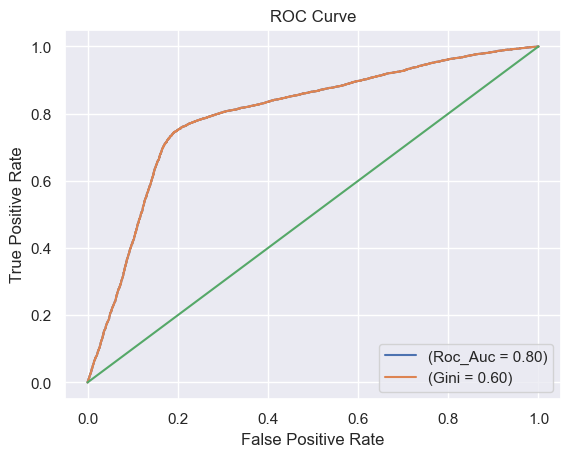

In [25]:
# Alinmish gini score uchun roc curve qrafiki yaradin.
y_prob = clf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
gini = (2*roc_auc_score(y_test, y_prob))-1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()

plt.plot(fpr, tpr, label='(Roc_Auc = %0.2f)' % roc_auc)
plt.plot(fpr, tpr, label='(Gini = %0.2f)' % gini)
plt.plot([0, 1], [0, 1])
plt.xlim()
plt.ylim()

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend(loc='lower right')
plt.show()

# Univariate analysis of Gini

In [26]:
# Her bir variable uchun Gini deyerini train ve test uzre gosterin
variables = []
train_gini_scores = []
test_gini_scores = []


for i in X_train.columns:
    X_train_single_var = X_train[[i]]
    X_test_single_var = X_test[[i]]

    
    clf.fit(X_train_single_var, y_train)
    
    y_pred_train_single_var = clf.predict_proba(X_train_single_var)[:, 1]

    train_roc = roc_auc_score(y_train, y_pred_train_single_var)
    train_gini = 2 * train_roc - 1

    
    y_pred_test_single_var = clf.predict_proba(X_test_single_var)[:, 1]

    test_roc = roc_auc_score(y_test, y_pred_test_single_var)
    test_gini = 2 * test_roc - 1


    variables.append(i)
    train_gini_scores.append(train_gini)
    test_gini_scores.append(test_gini)


results_df = pd.DataFrame({
                            'Variable': variables,
                            'Train Gini': train_gini_scores,
                            'Test Gini': test_gini_scores
                        })

results_df_sorted = results_df.sort_values(by='Test Gini', ascending=False)

pd.options.display.float_format = '{:.4f}'.format

results_df_sorted

,Variable,Train Gini,Test Gini
10,OutstandingDebt_woe,0.5106,0.5226
5,InterestRate_woe,0.4986,0.5049
9,NumCreditInquiries_woe,0.4430,0.4443
7,Delayfromduedate_woe,0.4162,0.4185
4,NumCreditCard_woe,0.3836,0.3866
6,NumofLoan_woe,0.3552,0.3506
3,NumBankAccounts_woe,0.3171,0.3234
11,PaymentofMinAmount_woe,0.3032,0.2996
8,NumofDelayedPayment_woe,0.2725,0.2751
13,MonthlyBalance_woe,0.2341,0.2435


In [27]:
results_df.Variable.tolist()

['Age_woe',
 'AnnualIncome_woe',
 'MonthlyInhandSalary_woe',
 'NumBankAccounts_woe',
 'NumCreditCard_woe',
 'InterestRate_woe',
 'NumofLoan_woe',
 'Delayfromduedate_woe',
 'NumofDelayedPayment_woe',
 'NumCreditInquiries_woe',
 'OutstandingDebt_woe',
 'PaymentofMinAmount_woe',
 'PaymentBehaviour_woe',
 'MonthlyBalance_woe']

# Secilmish variable-lar ile yeni model

In [28]:
# Univariate analysisde test uzre GINI deyeri 40 faizden yuxari olan deyishenler saxlanilaraq yeni model qurulur
filtered_df = results_df_sorted[
    (results_df_sorted['Test Gini'] > 0.40) &
    (abs(results_df_sorted['Train Gini'] - results_df_sorted['Test Gini']) <= 0.05)
]

filtered_df

,Variable,Train Gini,Test Gini
10,OutstandingDebt_woe,0.5106,0.5226
5,InterestRate_woe,0.4986,0.5049
9,NumCreditInquiries_woe,0.4430,0.4443
7,Delayfromduedate_woe,0.4162,0.4185


In [29]:
inputs_uni=data[['OutstandingDebt_woe',
 'InterestRate_woe',
 'NumCreditInquiries_woe',
 'Delayfromduedate_woe']]

output=data['score']


In [30]:
X_train_uni, X_test_uni, y_train_uni, y_test_uni = train_test_split(inputs_uni, output, test_size=0.3, random_state=35)

In [31]:
clf_uni = LogisticRegression()
clf_uni.fit(X_train_uni, y_train_uni)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
result_uni = evaluate(clf_uni, X_train_uni,  X_test_uni,y_train_uni, y_test_uni)

result_uni

(  Dataset    Gini  Precision  Recall
 0   Train 56.1766     0.6277  0.5803
 1    Test 56.9052     0.6321  0.5873,
 array([[15943,  2625],
        [ 3170,  4511]]))

# Deployment with woe

In [33]:
# Verilmish prod_data_with_woe.xlsx uchun modeli deploy edin.

# model.predict_proba() vasitesile mushterilerin default etme ehtimalini gosterin (PD)

In [34]:
path=r'‪C:\Users\User\Downloads\prod_data_with_woe.xlsx'
deploy_data=pd.read_excel(path[1:])
deploy_data

,Unnamed: 0,Age_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,NumCreditInquiries_woe,OutstandingDebt_woe,MonthlyBalance_woe,PaymentofMinAmount_woe,PaymentBehaviour_woe
0,66072,-0.1156,0.6777,0.6042,0.3233,0.0409,-0.0280,-0.1058,-1.0948,0.3325,1.1029,-0.3521,0.6836,0.9738,0.3910
1,6931,-0.1156,0.2314,-0.4757,0.3233,0.0409,-0.0280,0.3208,-0.1009,-0.2813,0.5585,-0.3521,-0.2370,-0.4725,-0.0706
2,3064,-0.0589,-0.1881,0.1639,0.7752,0.0409,-1.3762,0.9065,1.0508,0.6511,0.5585,-0.3521,0.6836,0.9738,0.1827
3,9134,-0.2219,0.2314,0.1639,-0.7832,-1.2249,-0.0280,0.3208,0.4968,0.3325,-1.0683,-1.2232,-0.4900,-0.4725,-0.3158
4,47254,-0.1156,-0.1881,-0.1572,-0.7832,0.0409,-1.3762,-0.1058,-1.0948,-0.6423,-0.4761,-1.2232,0.6836,-0.0110,0.1827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,52892,-0.2219,0.2314,-0.1572,-0.3802,-1.2249,-0.0280,-0.1058,-1.0948,-0.6423,-1.0683,-1.2232,0.2145,-0.4725,-0.3158
796,53553,0.4878,-0.1881,0.1639,0.3233,-0.0785,0.9632,0.3208,1.0508,-0.2813,1.1029,-0.3521,0.2145,-0.0110,0.3910
797,39282,-0.2219,-0.1881,-0.1572,-0.7832,-0.0785,-1.3762,-0.9635,-1.0948,-0.6423,-0.4761,-1.2232,-0.2370,-0.4725,-0.0034
798,53283,-0.0589,-0.5447,-0.4757,0.3233,-1.2249,-0.0280,0.9065,-0.1009,-0.2813,-0.4761,-1.2232,-0.4900,-0.0110,-0.3158


In [35]:
deploy_data.rename(columns={'Unnamed: 0':'Customer ID'},inplace=True)


In [36]:
deploy_data

,Customer ID,Age_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,NumCreditInquiries_woe,OutstandingDebt_woe,MonthlyBalance_woe,PaymentofMinAmount_woe,PaymentBehaviour_woe
0,66072,-0.1156,0.6777,0.6042,0.3233,0.0409,-0.0280,-0.1058,-1.0948,0.3325,1.1029,-0.3521,0.6836,0.9738,0.3910
1,6931,-0.1156,0.2314,-0.4757,0.3233,0.0409,-0.0280,0.3208,-0.1009,-0.2813,0.5585,-0.3521,-0.2370,-0.4725,-0.0706
2,3064,-0.0589,-0.1881,0.1639,0.7752,0.0409,-1.3762,0.9065,1.0508,0.6511,0.5585,-0.3521,0.6836,0.9738,0.1827
3,9134,-0.2219,0.2314,0.1639,-0.7832,-1.2249,-0.0280,0.3208,0.4968,0.3325,-1.0683,-1.2232,-0.4900,-0.4725,-0.3158
4,47254,-0.1156,-0.1881,-0.1572,-0.7832,0.0409,-1.3762,-0.1058,-1.0948,-0.6423,-0.4761,-1.2232,0.6836,-0.0110,0.1827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,52892,-0.2219,0.2314,-0.1572,-0.3802,-1.2249,-0.0280,-0.1058,-1.0948,-0.6423,-1.0683,-1.2232,0.2145,-0.4725,-0.3158
796,53553,0.4878,-0.1881,0.1639,0.3233,-0.0785,0.9632,0.3208,1.0508,-0.2813,1.1029,-0.3521,0.2145,-0.0110,0.3910
797,39282,-0.2219,-0.1881,-0.1572,-0.7832,-0.0785,-1.3762,-0.9635,-1.0948,-0.6423,-0.4761,-1.2232,-0.2370,-0.4725,-0.0034
798,53283,-0.0589,-0.5447,-0.4757,0.3233,-1.2249,-0.0280,0.9065,-0.1009,-0.2813,-0.4761,-1.2232,-0.4900,-0.0110,-0.3158


In [37]:
'''
'OutstandingDebt_woe',
 'InterestRate_woe',
 'NumCreditInquiries_woe',
 'Delayfromduedate_woe'

'''

"\n'OutstandingDebt_woe',\n 'InterestRate_woe',\n 'NumCreditInquiries_woe',\n 'Delayfromduedate_woe'\n\n"

In [38]:
data_new=deploy_data[['Customer ID','OutstandingDebt_woe',
 'InterestRate_woe',
 'NumCreditInquiries_woe',
 'Delayfromduedate_woe']]
data_new

,Customer ID,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe
0,66072,-0.3521,-0.0280,1.1029,-1.0948
1,6931,-0.3521,-0.0280,0.5585,-0.1009
2,3064,-0.3521,-1.3762,0.5585,1.0508
3,9134,-1.2232,-0.0280,-1.0683,0.4968
4,47254,-1.2232,-1.3762,-0.4761,-1.0948
...,...,...,...,...,...
795,52892,-1.2232,-0.0280,-1.0683,-1.0948
796,53553,-0.3521,0.9632,1.1029,1.0508
797,39282,-1.2232,-1.3762,-0.4761,-1.0948
798,53283,-1.2232,-0.0280,-0.4761,-0.1009


In [39]:
data_new['pd_score']=clf_uni.predict_proba(data_new.iloc[:,1:])[:,1]
data_new

C:\Users\User\AppData\Local\Temp\ipykernel_13520\3657136614.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_new['pd_score']=clf_uni.predict_proba(data_new.iloc[:,1:])[:,1]


,Customer ID,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe,pd_score
0,66072,-0.3521,-0.0280,1.1029,-1.0948,0.3295
1,6931,-0.3521,-0.0280,0.5585,-0.1009,0.3033
2,3064,-0.3521,-1.3762,0.5585,1.0508,0.3629
3,9134,-1.2232,-0.0280,-1.0683,0.4968,0.4699
4,47254,-1.2232,-1.3762,-0.4761,-1.0948,0.6754
...,...,...,...,...,...,...
795,52892,-1.2232,-0.0280,-1.0683,-1.0948,0.5776
796,53553,-0.3521,0.9632,1.1029,1.0508,0.1515
797,39282,-1.2232,-1.3762,-0.4761,-1.0948,0.6754
798,53283,-1.2232,-0.0280,-0.4761,-0.1009,0.4700


# Deployment with real values (homework)

In [40]:
# Verilmish test_data_real_values.xlsx uchun modeli deploy edin. 
import pandas as pd
# verilmish test datasinda mushterilerin default etme ehtimalini gosterin (PD)
path=r'‪C:\Users\User\Downloads\test_data_real_values.xlsx'
data_real=pd.read_excel(path[1:])
data_real

,OutstandingDebt,InterestRate,NumCreditInquiries,Delayfromduedate,CustomerID
0,632.9300,17,0,20,53115
1,3259.1700,24,11,53,35538
2,2313.6000,22,11,55,15150
3,556.8500,16,8,23,65145
4,1115.0600,6,3,16,23224
...,...,...,...,...,...
995,1360.3100,11,8,6,86109
996,1213.2600,11,6,22,62411
997,1509.7200,27,11,18,5554
998,356.6900,18,9,25,70288


In [41]:
data_real.describe(include='all')

,OutstandingDebt,InterestRate,NumCreditInquiries,Delayfromduedate,CustomerID
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,1417.0545,15.3430,6.4160,20.9000,43764.8210
std,1109.4079,9.3965,4.3416,14.4377,25329.9021
min,0.7700,1.0000,0.0000,-3.0000,52.0000
25%,572.3425,8.0000,3.0000,10.0000,21709.7500
50%,1153.7700,14.0000,6.0000,18.0000,44880.0000
75%,1941.2475,22.0000,9.0000,28.0000,65438.2500
max,4022.8500,38.0000,18.0000,55.0000,87424.0000


In [42]:
data_real.columns

Index(['OutstandingDebt', 'InterestRate', 'NumCreditInquiries',
       'Delayfromduedate', 'CustomerID'],
      dtype='object')

In [44]:
woe_columns=['OutstandingDebt', 'InterestRate', 'NumCreditInquiries',
       'Delayfromduedate']

for var in woe_columns:
    
    
    q1=data[var].quantile(0.25)
    q2=data[var].quantile(0.5)
    q3=data[var].quantile(0.75)
    
    ranges=[-np.inf,q1,q2,q3,np.inf]
    
    data_real['category_'+var]=pd.cut(data_real[var],bins=ranges,duplicates='drop')

    

for var in woe_columns:
    woe_table=data[['category_'+var,var+'_woe']].drop_duplicates().dropna()
    data_real=data_real.merge(woe_table,on='category_'+var,how='left')
    

In [45]:
data_real.columns

Index(['OutstandingDebt', 'InterestRate', 'NumCreditInquiries',
       'Delayfromduedate', 'CustomerID', 'category_OutstandingDebt',
       'category_InterestRate', 'category_NumCreditInquiries',
       'category_Delayfromduedate', 'OutstandingDebt_woe', 'InterestRate_woe',
       'NumCreditInquiries_woe', 'Delayfromduedate_woe'],
      dtype='object')

In [46]:
data_new_real=data_real[['CustomerID',
                            'OutstandingDebt_woe',
                            'InterestRate_woe',
                            'NumCreditInquiries_woe',
                            'Delayfromduedate_woe']]

In [47]:
data_new_real['pd_score']=clf_uni.predict_proba(data_new_real.iloc[:,1:])[:,1]
data_new_real

C:\Users\User\AppData\Local\Temp\ipykernel_13520\3778888047.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_new_real['pd_score']=clf_uni.predict_proba(data_new_real.iloc[:,1:])[:,1]


,CustomerID,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe,pd_score
0,53115,1.2096,-0.0280,1.1029,-0.1009,0.1483
1,35538,-1.2232,-1.3762,-1.0683,-1.0948,0.7099
2,15150,-1.2232,-1.3762,-1.0683,-1.0948,0.7099
3,65145,1.2719,-0.0280,-0.4761,-0.1009,0.2066
4,23224,1.2096,0.9632,1.1029,0.4968,0.0880
...,...,...,...,...,...,...
995,86109,-0.3521,1.1494,-0.4761,1.0508,0.2026
996,62411,-0.3521,1.1494,0.5585,-0.1009,0.2075
997,5554,-0.3521,-1.3762,-1.0683,0.4968,0.5085
998,70288,1.2719,-0.0280,-0.4761,-0.1009,0.2066
